In [1]:
import time
import json
import csv

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler import CouplingMap, PassManager
from pathlib import Path
from typing import Dict, List, Iterable
from util import EAGLE_COUPLING, sabre, count_swaps 
from multilevel_sabre import MultiLevelSabre
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import SabreLayout, SetLayout, SabreSwap, RemoveFinalMeasurements
from qiskit.converters import circuit_to_dag, dag_to_circuit

random_seed = 1

Coupling map

In [2]:
from util import EAGLE_COUPLING

coupling_map = CouplingMap(couplinglist=EAGLE_COUPLING)
coupling_map.make_symmetric()

Select Circuit

In [3]:
filename = "circuits/dnn_n51.qasm"
qc = QuantumCircuit.from_qasm_file(filename)
qc_dag = circuit_to_dag(qc)
qc_dag = RemoveFinalMeasurements().run(qc_dag)
qc = dag_to_circuit(qc_dag)

For layout considerations

In [4]:
num_program_qubit=qc.num_qubits
num_classical_bits=qc.num_clbits
num_physical_qubit=max(max(i) for i in coupling_map)+1
if num_physical_qubit>num_program_qubit:
    temp_qc=QuantumCircuit(num_physical_qubit,num_classical_bits)
    temp_qc.compose(qc,inplace=True)
    qc=temp_qc

In [5]:
qr = qc.qregs[0]
qr

QuantumRegister(127, 'q')

Sabre PM 

In [6]:
pm_sabre = generate_preset_pass_manager(optimization_level=3, coupling_map=coupling_map, seed_transpiler=random_seed)
qc_tr_sabre = pm_sabre.run(qc)

swaps_sabre = count_swaps(qc_tr_sabre)
depth_2q_sabre = qc_tr_sabre.depth(lambda x: x.operation.num_qubits == 2)
print(f"SABRE: SWAPs={swaps_sabre}, 2Q Depth={depth_2q_sabre}")


SABRE: SWAPs=6, 2Q Depth=65


SABRE ML PM

In [7]:
pm_ml_sabre = PassManager([
    MultiLevelSabre(
        coupling_graph=coupling_map,
        cycles=10,
        random_seed=1,
        coarsest_solving_trials=50,
        num_interpolation=10,
        use_initial_embedding=True,
        verbose=0
    )
])
qc_tr_ml_sabre = pm_ml_sabre.run(qc)

swaps_ml_sabre = count_swaps(qc_tr_ml_sabre)
depth_2q_ml_sabre = qc_tr_ml_sabre.depth(lambda x: x.operation.num_qubits == 2)


In [8]:
print(f"ML-SABRE: SWAPs={swaps_ml_sabre}, 2Q Depth={depth_2q_ml_sabre}")

ML-SABRE: SWAPs=0, 2Q Depth=52


In [9]:
qc_tr_ml_sabre.count_ops()

OrderedDict([('ry', 50),
             ('rz', 50),
             ('cswap', 25),
             ('rzz', 24),
             ('cry', 24),
             ('crz', 24),
             ('h', 2),
             ('ryy', 1),
             ('ryy_140578989711904', 1),
             ('ryy_140578989712096', 1),
             ('ryy_140578989712192', 1),
             ('ryy_140578989712288', 1),
             ('ryy_140578989712384', 1),
             ('ryy_140578989712480', 1),
             ('ryy_140578989712576', 1),
             ('ryy_140578989712672', 1),
             ('ryy_140578989712768', 1),
             ('ryy_140578989712864', 1),
             ('ryy_140578989712960', 1),
             ('ryy_140578989713056', 1),
             ('ryy_140578989713152', 1),
             ('ryy_140578989713248', 1),
             ('ryy_140578989713344', 1),
             ('ryy_140578989713440', 1),
             ('ryy_140578989713536', 1),
             ('ryy_140578989713632', 1),
             ('ryy_140578989713728', 1),
             ('ry

In [13]:
directory = "circuits/"
circuit_files = []
for file in Path(directory).glob("*.qasm"):
    circuit_files.append(file)
print(f"Found {len(circuit_files)} circuit files.")    

Found 12 circuit files.


In [14]:
for qasm_path in circuit_files:
    qc = QuantumCircuit.from_qasm_file(qasm_path)
    qc_name = qasm_path.stem
    print(f"\nProcessing circuit: {qc_name}")

    ops = qc.count_ops()
    print(f"    Original circuit ops: {ops}")



Processing circuit: wstate_n118
    Original circuit ops: OrderedDict({'ry': 234, 'measure': 118, 'cz': 117, 'cx': 117, 'x': 1, 'barrier': 1})

Processing circuit: swap_test_n83
    Original circuit ops: OrderedDict({'rx': 82, 'cswap': 41, 'h': 2, 'measure': 1})

Processing circuit: knn_67
    Original circuit ops: OrderedDict({'ry': 66, 'cswap': 33, 'h': 2, 'measure': 1})

Processing circuit: dnn_n51
    Original circuit ops: OrderedDict({'measure': 51, 'ry': 50, 'rz': 50, 'cswap': 25, 'rzz': 24, 'cry': 24, 'crz': 24, 'h': 2, 'ryy': 1, 'ryy_140578989711904': 1, 'ryy_140578989712096': 1, 'ryy_140578989712192': 1, 'ryy_140578989712288': 1, 'ryy_140578989712384': 1, 'ryy_140578989712480': 1, 'ryy_140578989712576': 1, 'ryy_140578989712672': 1, 'ryy_140578989712768': 1, 'ryy_140578989712864': 1, 'ryy_140578989712960': 1, 'ryy_140578989713056': 1, 'ryy_140578989713152': 1, 'ryy_140578989713248': 1, 'ryy_140578989713344': 1, 'ryy_140578989713440': 1, 'ryy_140578989713536': 1, 'ryy_140578989

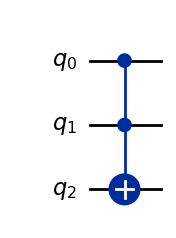

In [12]:
qc_ccx = QuantumCircuit(3)
qc_ccx.ccx(0, 1, 2)
qc_ccx.draw('mpl')